
Training Random Forest...
----------------------------------------
Random Forest Model Accuracy: 0.8361

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61

Confusion Matrix:
[[19  9]
 [ 1 32]]


Training K-Nearest Neighbors...
----------------------------------------
K-Nearest Neighbors Model Accuracy: 0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

Confusion Matrix:
[[19  9]
 [ 3 30]]



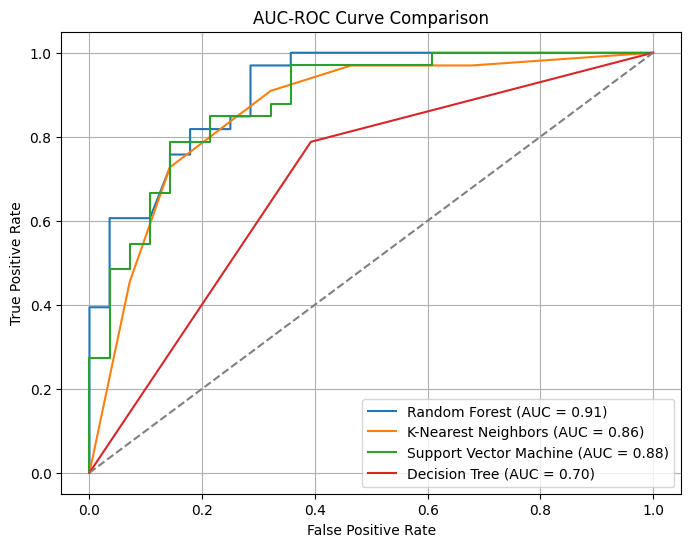

<ipython-input-4-d3e66e739b90>:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=metrics_df, ax=axes[0, 0], palette="viridis")
<ipython-input-4-d3e66e739b90>:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Precision", data=metrics_df, ax=axes[0, 1], palette="coolwarm")
<ipython-input-4-d3e66e739b90>:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Recall", data=metrics_df, ax=axes[1, 0], palette="Blues_r")
<ipython-input-4-d3e66e739b90>:115: FutureWarning: 

Passing `palette` wi

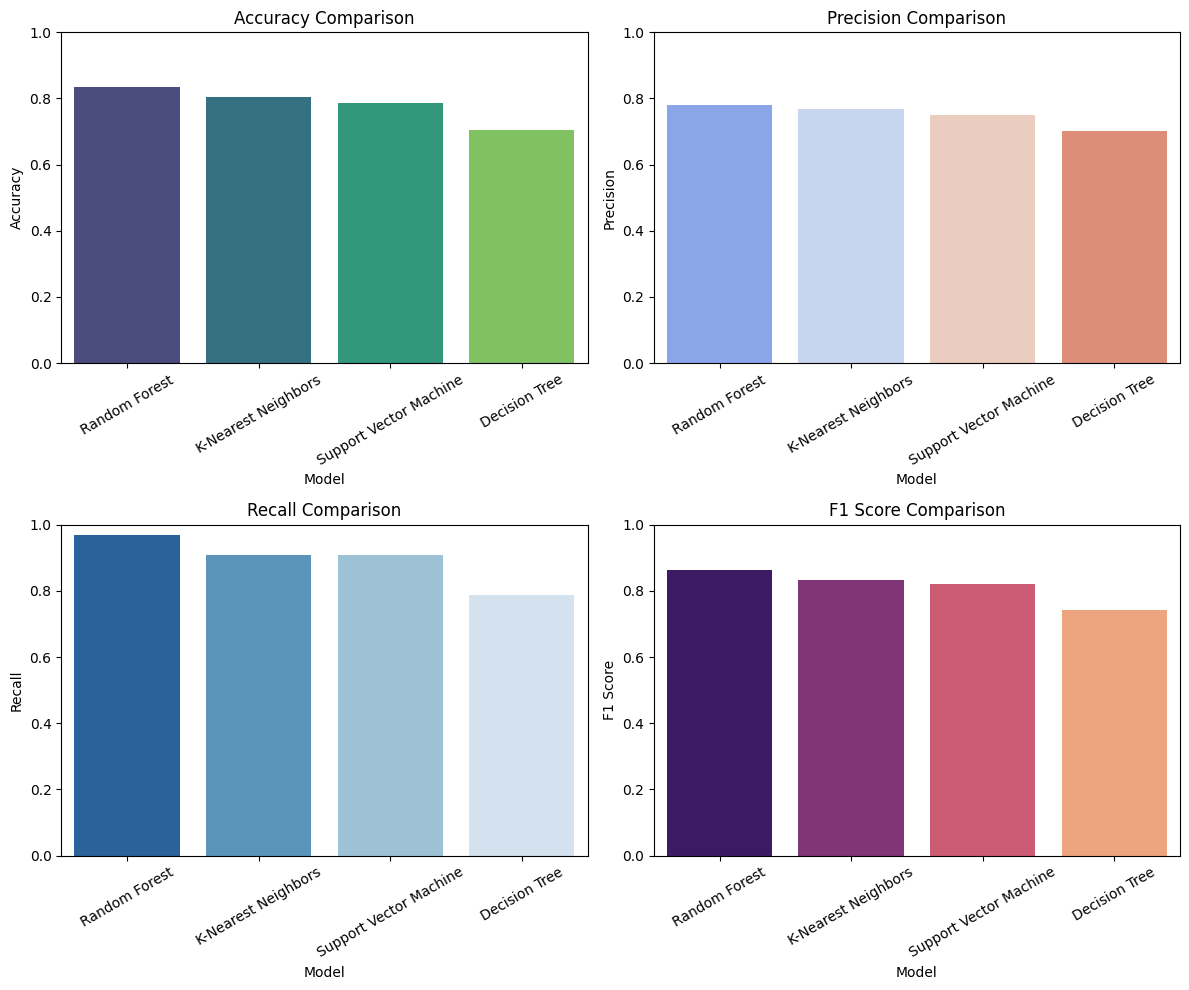

In [ ]:
#K.Jaswanth[2022BCS0147]
#M.Naresh[2022BCD0024]

# Install necessary libraries (if not already installed)
!pip install pandas numpy seaborn matplotlib scikit-learn xgboost

# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_curve, auc
)

# Load the dataset (Update path if needed)
file_path = "heart.csv"  # Changed to local repository path
df = pd.read_csv(file_path)

# Data Preprocessing
df.dropna(inplace=True)  # Drop missing values
X = df.drop(columns=['target'])  # Features
y = df['target']  # Target variable

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='linear', probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Store evaluation metrics
metrics = {"Model": [], "Accuracy": [], "Precision": [], "Recall": [], "F1 Score": []}

# AUC-ROC Plot
plt.figure(figsize=(8, 6))

for name, model in models.items():
    print(f"\nTraining {name}...\n" + "-"*40)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store in dictionary
    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy)
    metrics["Precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["F1 Score"].append(f1)

    print(f"{name} Model Accuracy: {accuracy:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n" + "="*50)

    # AUC-ROC Curve
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot AUC-ROC Curve
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Convert metrics dictionary to DataFrame
metrics_df = pd.DataFrame(metrics)

# Plot Accuracy, Precision, Recall, and F1 Score Comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy
sns.barplot(x="Model", y="Accuracy", data=metrics_df, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Accuracy Comparison")
axes[0, 0].set_ylim(0, 1)

# Precision
sns.barplot(x="Model", y="Precision", data=metrics_df, ax=axes[0, 1], palette="coolwarm")
axes[0, 1].set_title("Precision Comparison")
axes[0, 1].set_ylim(0, 1)

# Recall
sns.barplot(x="Model", y="Recall", data=metrics_df, ax=axes[1, 0], palette="Blues_r")
axes[1, 0].set_title("Recall Comparison")
axes[1, 0].set_ylim(0, 1)

# F1 Score
sns.barplot(x="Model", y="F1 Score", data=metrics_df, ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("F1 Score Comparison")
axes[1, 1].set_ylim(0, 1)

# Improve plot readability
for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()


In [ ]:
import os
print(os.listdir("."))


['.config', 'sample_data']


In [ ]:
import pandas as pd

file_path = "heart.csv"  # Changed to local repository path
df = pd.read_csv(file_path)

print("Dataset Columns:\n", df.columns)


Dataset Columns:
 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [ ]:
!pip install pandas numpy seaborn matplotlib scikit-learn xgboost
